<h4 style="color: white";><strong>Exploración de datos BCI </strong> </h4>
<p style="font-style: italic;">Karen Agudelo Toro, Luisa Maria Hernández </p>

Consultar historia, uso y proyectos futuros relacionados con Interfaz Cerebro Computador

<p>
Esta tecnología decodifica y convierte los impulsos cerebrales en instrucciones que pueden usarse para operar computadoras, prótesis u otros dispositivos [1].Desde el punto de vista terminológico, BCI se refiere a un sistema que mide y utiliza señales adquiridas del sistema nervioso central (SNC) [2]. 
Las interfaces cerebro-computadora se clasifican según su interacción con el cerebro: las BCI invasivas implican la implantación quirúrgica de electrodos en la superficie o el interior del cerebro, proporcionando señales precisas pero conllevando mayores riesgos y dilemas éticos; por otro lado, las BCI no invasivas utilizan sensores externos, como electrodos de EEG, para detectar señales cerebrales. [1]

HISTORIA
Las interfaces cerebro- computadora (BCI) tardaron muchas décadas en evolucionar desde meras ideas teóricas hasta aplicaciones prácticas, a partir de los primeros estudios en neurofisiología y la introducción de la electroencefalografía (EEG) en el siglo XX[1]. La historia del EEG comenzó


USO
Estos sistemas pueden ayudar a algunos usuarios con discapacidad a interactuar con el entorno externo de una manera más directa, intuitiva y fácil de usar. [2]

FUTURO



<p>

In [1]:
import mne
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def procesar_eeg_bci(raw, f_min=0.5, f_max=45.0, metodo_filtro='fir'):
    """
    Aplica el flujo de procesamiento: Filtrado Notch y Pasa-Banda.
    Permite elegir entre FIR (preciso) e IIR (rápido para BCI).
    """
    # 1. Copia de seguridad para comparar
    raw_original = raw.copy()
    
    # 2. Eliminar ruido de línea eléctrica (60 Hz en Colombia/USA)
    # El Notch es esencial para limpiar la interferencia de la red
    raw_filt = raw.copy().notch_filter(freqs=60, method=metodo_filtro)
    
    # 3. Filtro Pasa-Banda (0.5 - 45 Hz)
    # IIR es más rápido (menor orden), ideal para procesamiento en tiempo real
    # FIR es de fase lineal (no desfasa la señal), pero consume más CPU
    raw_filt.filter(l_freq=f_min, h_freq=f_max, method=metodo_filtro, verbose=False)
    
    return raw_original, raw_filt

# --- EJECUCIÓN CON TUS DATOS ---

# Cargar
path = 'sub-001_task-motion_run-4_eeg.set'
raw = mne.io.read_raw_eeglab(path, preload=True)

# Procesar usando IIR por su eficiencia en BCI
raw_org, raw_proc = procesar_eeg_bci(raw, metodo_filtro='iir')

# --- VISUALIZACIÓN PARA EL INFORME ---

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Graficar un canal específico (ej. Cz) para ver la diferencia
start, stop = raw.time_as_index([10, 15]) # Segmento de 5 segundos
canal = raw.ch_names.index('Cz')

ax[0].plot(raw.times[start:stop], raw_org.get_data()[canal, start:stop], color='red', alpha=0.6)
ax[0].set_title("Señal Original (Con Drift y Ruido)")
ax[0].set_ylabel("µV")

ax[1].plot(raw.times[start:stop], raw_proc.get_data()[canal, start:stop], color='blue')
ax[1].set_title("Señal Procesada (Filtro Notch 60Hz + Pasa-Banda 0.5-45Hz)")
ax[1].set_xlabel("Tiempo (s)")
ax[1].set_ylabel("µV")

plt.tight_layout()
plt.show()

# Comparación de Espectro (PSD) para el informe
raw_org.plot_psd(fmax=70)
raw_proc.plot_psd(fmax=70)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 1057 samples (6.606 s)



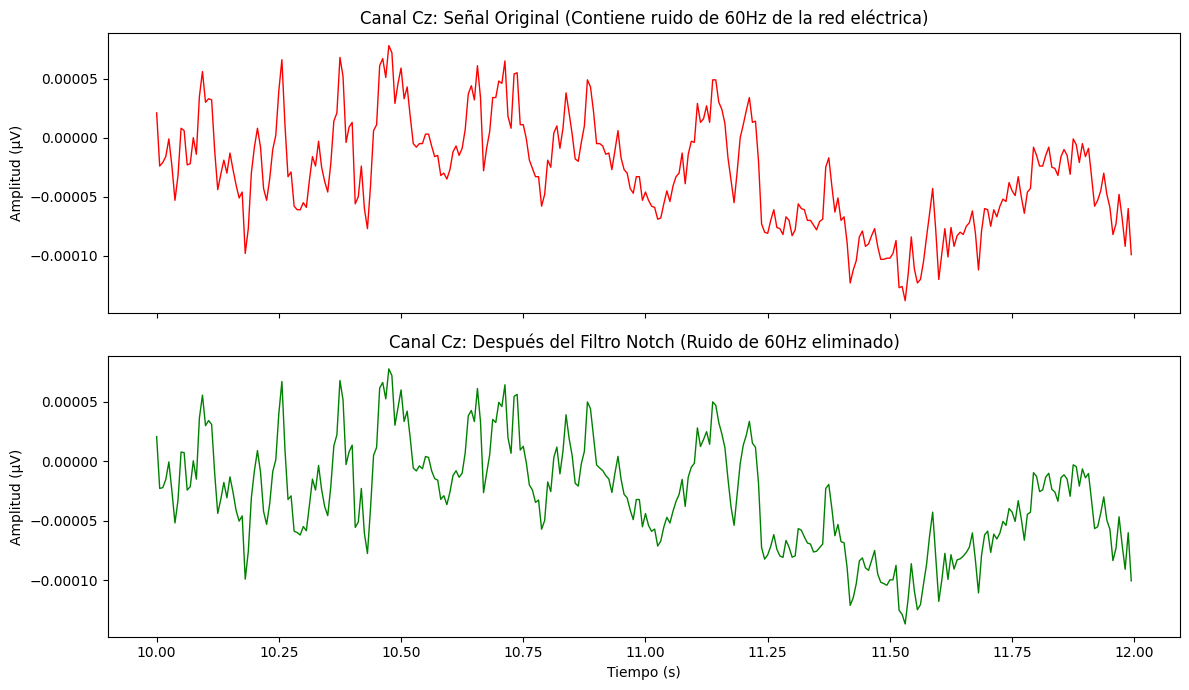

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


c:\Users\lmari\miniconda3\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
c:\Users\lmari\miniconda3\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


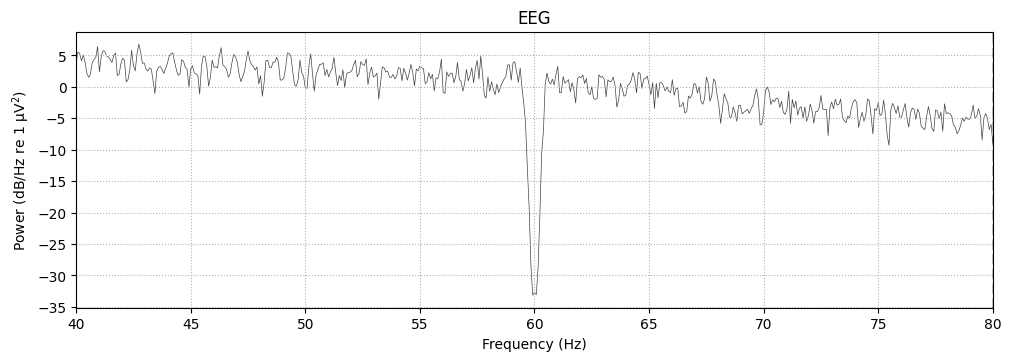

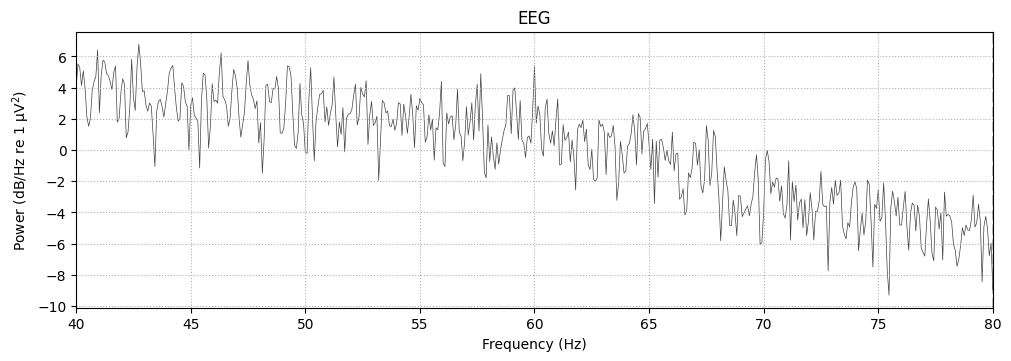

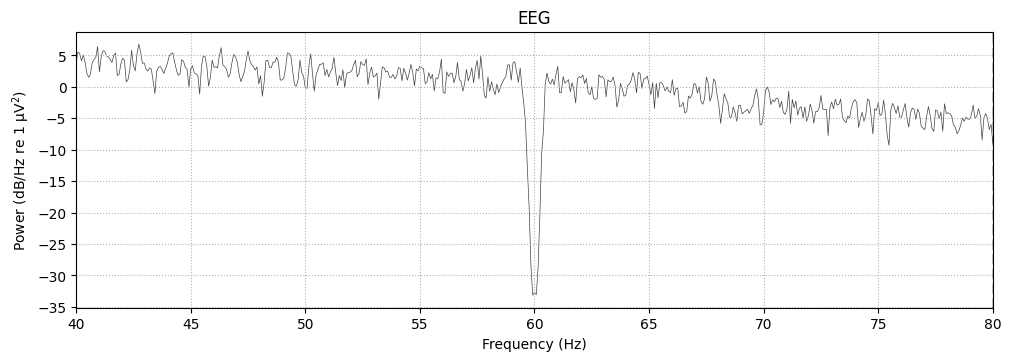

In [ ]:


# 1. Definir la ruta y cargar el archivo (usando 'r' para evitar errores de dirección)
path = r"sub-001_task-motion_run-4_eeg.set"
raw = mne.io.read_raw_eeglab(path, preload=True)

# 2. Crear una copia y aplicar  el filtro Notch (60 Hz)

raw_notch = raw.copy().notch_filter(freqs=60, method='fir')

# 3. Extraer datos para graficar y comparar
# Elegimos el canal 'Cz' y un segmento de 2 segundos para que el ruido sea visible
canal = 'Cz'
canal_idx = raw.ch_names.index(canal)
start, stop = raw.time_as_index([10, 12])  # Del segundo 10 al 12

tiempos = raw.times[start:stop]
señal_original = raw.get_data()[canal_idx, start:stop]
señal_con_notch = raw_notch.get_data()[canal_idx, start:stop]

# --- GRAFICAR ---
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Señal Original
ax[0].plot(tiempos, señal_original, color='red', lw=1)
ax[0].set_title(f"Canal {canal}: Señal Original (Contiene ruido de 60Hz de la red eléctrica)")
ax[0].set_ylabel("Amplitud (µV)")

# Señal con Notch
ax[1].plot(tiempos, señal_con_notch, color='green', lw=1)
ax[1].set_title(f"Canal {canal}: Después del Filtro Notch (Ruido de 60Hz eliminado)")
ax[1].set_xlabel("Tiempo (s)")
ax[1].set_ylabel("Amplitud (µV)")

plt.tight_layout()
plt.show()

# --- COMPROBACIÓN ESPECTRAL (PSD) ---

raw.plot_psd(fmin=40, fmax=80, picks=[canal])      
raw_notch.plot_psd(fmin=40, fmax=80, picks=[canal]) 

<h4 style="color: white";><strong>Bibliografía </strong> </h4>

<p>[1] https://www.sciencedirect.com/science/article/pii/S2590093525000049<p>
<p>[2] https://pmc.ncbi.nlm.nih.gov/articles/PMC7824107/<p>
<p>[3] https://magazine.hms.harvard.edu/articles/designing-brain-computer-interfaces-connect-neurons-digital-world<p>
<p>[4] https://www.researchgate.net/publication/360402909_Brain-Computer_Interfaces_The_Technology_of_Our_Future<p>
<p>[5]https://www.news-medical.net/health/Brain-Computer-Interfaces-What-They-Are-and-Why-They-Matter.aspx<p>
<p>[6]https://pubmed.ncbi.nlm.nih.gov/38711277/<p>
